# Telco Customer Churn - Exploratory Data Analysis

**Dataset:** IBM Telco Customer Churn (Kaggle)
**Goal:** Understand what drives customers to cancel their subscription.

An EDA answers questions *before* any modelling:
- What does the data look like?
- Are there missing or broken values?
- Which features separate churners from non-churners?

**Steps:**
1. Setup
2. Load data
3. First look: shape, dtypes, describe
4. Missing value check
5. Data cleaning
6. Univariate analysis (single variable)
7. Bivariate analysis (variable vs churn)
8. Correlation heatmap
9. Key takeaways

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

Libraries loaded!


## 2. Load Data

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. First Look

### 3.1 Shape and dtypes

In [5]:
print("Rows / Columns:", df.shape)
df.info()

Rows / Columns: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

### 3.2 Descriptive Statistics

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Value Check

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])
print("\nTotal missing cells:", missing.sum())

Series([], dtype: int64)

Total missing cells: 0


## 5. Data Cleaning

Two issues are common in this dataset:

1. `TotalCharges` is stored as a string — must be converted to numeric.  
   Customers with `tenure = 0` have a blank `TotalCharges`, which becomes `NaN`.  
   We fill those with `0` (no charges yet).

2. `Churn` is Yes/No — we create a numeric flag `churned` (1 = left, 0 = stayed)  
   for easier aggregation later.

3. `SeniorCitizen` is already 0/1 but we add a readable label for plots.


In [8]:
# Fix TotalCharges dtype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("NaN in TotalCharges after conversion:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Binary churn flag
df["churned"] = (df["Churn"] == "Yes").astype(int)

# Readable senior citizen label
df["senior_label"] = np.where(df["SeniorCitizen"] == 1, "Senior", "Non-Senior")

df[["TotalCharges", "Churn", "churned", "SeniorCitizen", "senior_label"]].head()

NaN in TotalCharges after conversion: 11


,TotalCharges,Churn,churned,SeniorCitizen,senior_label
0,29.85,No,0,0,Non-Senior
1,1889.50,No,0,0,Non-Senior
2,108.15,Yes,1,0,Non-Senior
3,1840.75,No,0,0,Non-Senior
4,151.65,Yes,1,0,Non-Senior


## 6. Univariate Analysis

Understand each variable on its own before comparing to churn.

### 6.1 Overall Churn Rate

Overall churn rate: 26.5%


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_1575/1181632803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["steelblue", "tomato"])


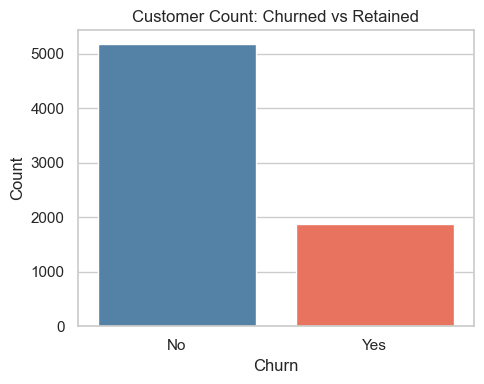

In [9]:
churn_rate = df["churned"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette=["steelblue", "tomato"])
plt.title("Customer Count: Churned vs Retained")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 6.2 Tenure Distribution

How long have customers been with the company?

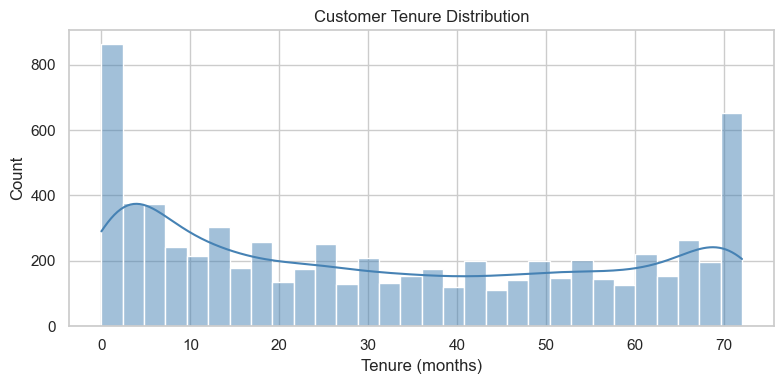

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df["tenure"], bins=30, color="steelblue", kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["tenure"].describe())

In [ ]:
### 6.3 Monthly Charges Distribution

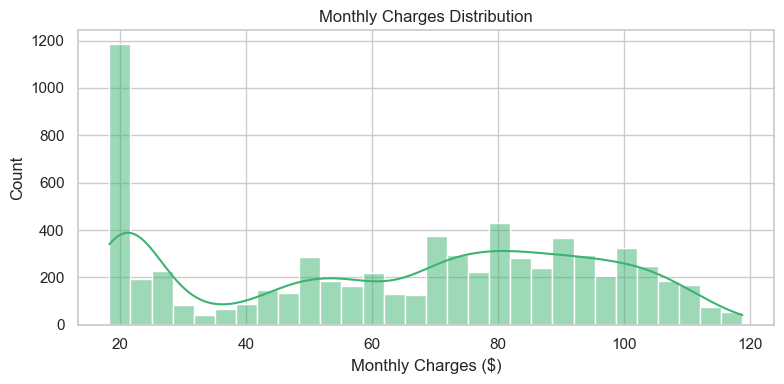

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df["MonthlyCharges"], bins=30, color="mediumseagreen", kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 6.4 Contract Type Breakdown

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_1575/332414583.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


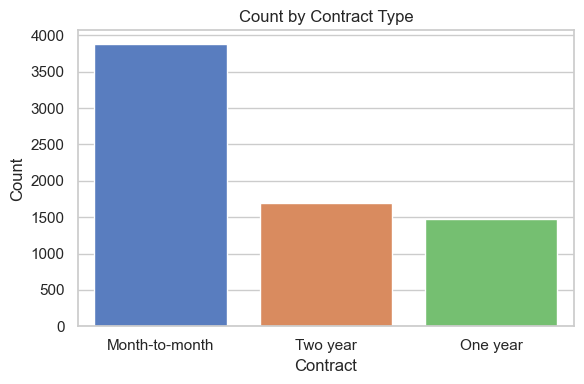

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="Contract",
    order=df["Contract"].value_counts().index,
    palette="muted"
)
plt.title("Count by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Each Feature vs Churn

### 7.1 Churn Rate by Contract Type

Hypothesis: month-to-month customers churn more — no commitment locks them in.

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_1575/3388047782.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_contract, x="Contract", y="churn_rate", palette="Reds_d")


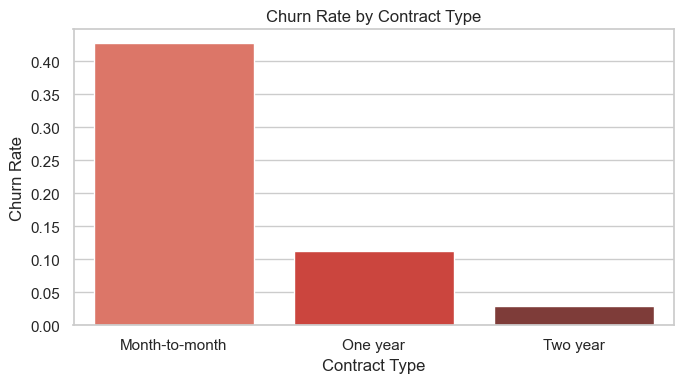

         Contract  churn_rate
0  Month-to-month    0.427097
1        One year    0.112695
2        Two year    0.028319


In [13]:
churn_contract = (
    df.groupby("Contract")["churned"]
    .mean()
    .reset_index()
    .sort_values("churned", ascending=False)
    .rename(columns={"churned": "churn_rate"})
)

plt.figure(figsize=(7, 4))
sns.barplot(data=churn_contract, x="Contract", y="churn_rate", palette="Reds_d")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

print(churn_contract)

### 7.2 Tenure vs Churn

Do churners leave early, or does it happen at any tenure length?

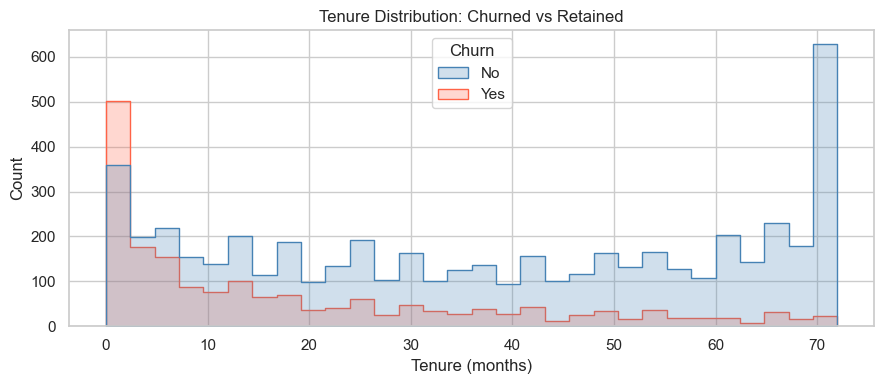

In [14]:
plt.figure(figsize=(9, 4))
sns.histplot(
    data=df, x="tenure", hue="Churn",
    bins=30, element="step",
    palette={"No": "steelblue", "Yes": "tomato"}
)
plt.title("Tenure Distribution: Churned vs Retained")
plt.xlabel("Tenure (months)")
plt.tight_layout()
plt.show()


### 7.3 Monthly Charges vs Churn

Do churners pay more per month?

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_1575/4171854339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


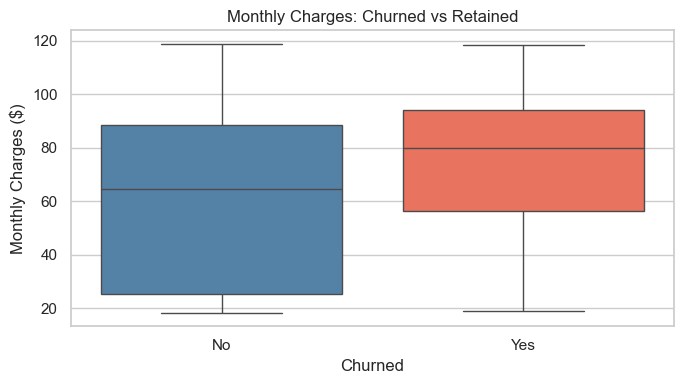

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [15]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df, x="Churn", y="MonthlyCharges",
    palette={"No": "steelblue", "Yes": "tomato"}
)
plt.title("Monthly Charges: Churned vs Retained")
plt.xlabel("Churned")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].describe())

### 7.4 Churn Rate by Payment Method

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_1575/52787235.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_payment, x="PaymentMethod", y="churn_rate", palette="Oranges_d")


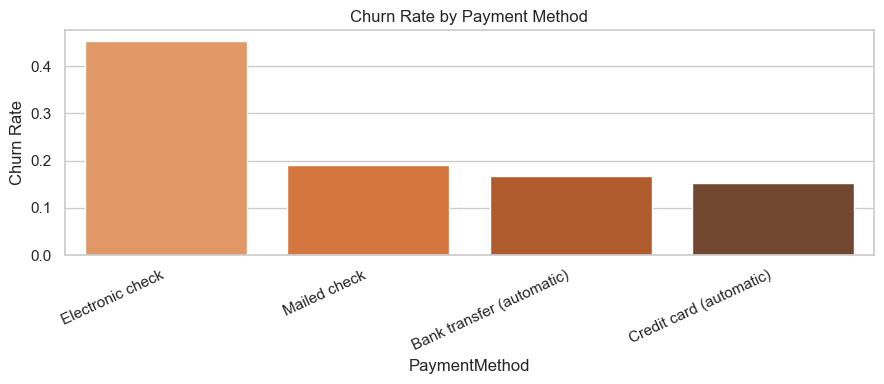

               PaymentMethod  churn_rate
2           Electronic check    0.452854
3               Mailed check    0.191067
0  Bank transfer (automatic)    0.167098
1    Credit card (automatic)    0.152431


In [16]:
churn_payment = (
    df.groupby("PaymentMethod")["churned"]
    .mean()
    .reset_index()
    .sort_values("churned", ascending=False)
    .rename(columns={"churned": "churn_rate"})
)

plt.figure(figsize=(9, 4))
sns.barplot(data=churn_payment, x="PaymentMethod", y="churn_rate", palette="Oranges_d")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

print(churn_payment)

### 7.5 Internet Service vs Churn (Crosstab)

What share of each internet service group churns?

Churn               No    Yes
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074


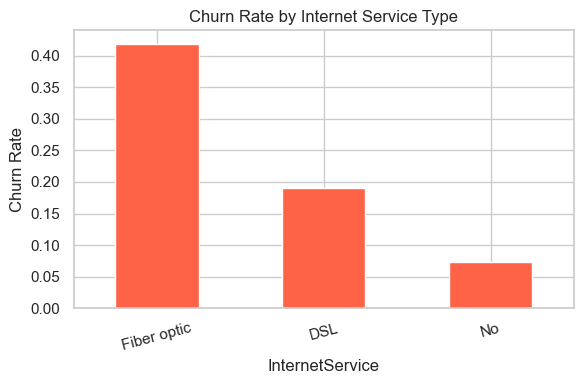

In [17]:
ct = pd.crosstab(df["InternetService"], df["Churn"], normalize="index").round(3)
print(ct)

ct["Yes"].sort_values(ascending=False).plot(
    kind="bar", figsize=(6, 4), color="tomato", edgecolor="white"
)
plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 7.6 Senior Citizens vs Churn

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_1575/1435464273.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_senior, x="senior_label", y="churn_rate", palette="Purples_d")


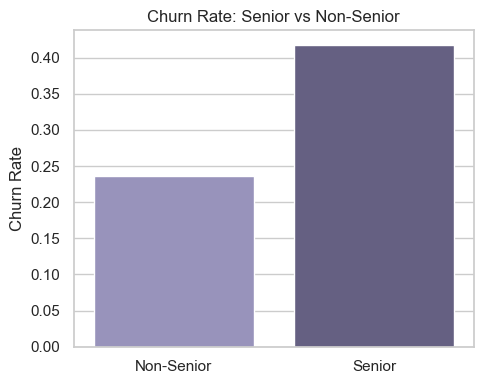

  senior_label  churn_rate
0   Non-Senior    0.236062
1       Senior    0.416813


In [18]:
churn_senior = (
    df.groupby("senior_label")["churned"]
    .mean()
    .reset_index()
    .rename(columns={"churned": "churn_rate"})
)

plt.figure(figsize=(5, 4))
sns.barplot(data=churn_senior, x="senior_label", y="churn_rate", palette="Purples_d")
plt.title("Churn Rate: Senior vs Non-Senior")
plt.xlabel("")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

print(churn_senior)

## 8. Correlation Heatmap

Which numeric features are most related to churn?

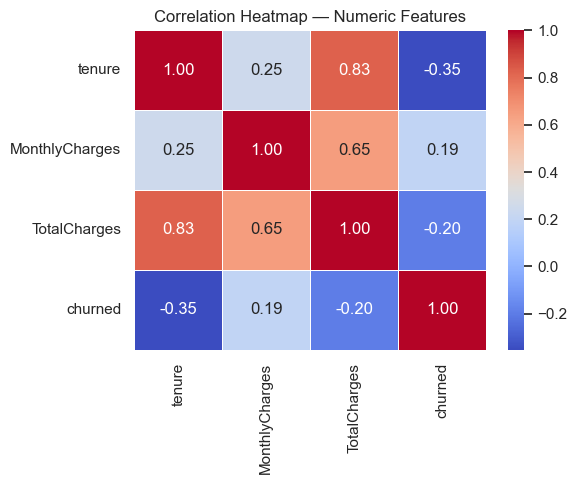

In [19]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "churned"]
corr     = df[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

## 9. Key Takeaways

| Finding | Detail |
|---|---|
| **Overall churn rate** | ~26% of customers churned |
| **Contract type** | Month-to-month customers churn at ~42%; two-year contracts at ~3% |
| **Tenure** | Most churners leave within the first 10 months |
| **Monthly charges** | Churners pay ~$10–15 more per month on average |
| **Payment method** | Electronic check users have the highest churn rate |
| **Internet service** | Fiber optic customers churn more than DSL users |
| **Senior citizens** | Senior customers churn at a higher rate than non-seniors |
| **Correlation** | `tenure` negatively correlates with churn; `MonthlyCharges` positively |

> **Business implication:**  
> The riskiest customer profile is: month-to-month contract + fiber optic + electronic check + low tenure.  
> Targeted retention offers for this group could meaningfully reduce churn.